# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [211]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [212]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [213]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index

In [214]:
prices = yf.download(interval="1mo", period="max", auto_adjust=True, progress=False, tickers=tickers)["Close"]
prices.index = pd.to_datetime(adj_close.index)
prices = prices.sort_index()
prices.tail()

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-12-01,271.605835,349.989990,214.160004,263.823273,659.165161,658.987854,482.518677,153.190002,186.479538,193.719543
2026-01-01,259.237427,293.250000,236.729996,211.760376,496.468567,715.887085,429.310120,117.010002,191.119659,163.574799
2026-02-01,263.933014,262.410004,200.210007,194.304047,407.769867,647.625488,391.845612,108.010002,177.180420,144.893936
2026-03-01,253.789993,243.080002,203.429993,186.204300,431.047943,571.640564,370.170013,104.550003,174.390549,146.597992
2026-04-01,273.429993,238.979996,305.329987,173.300003,383.299988,659.150024,415.750000,84.779999,199.639999,176.279999


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [215]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties


In [216]:
prices.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    496 non-null    float64
 1   ADBE    477 non-null    float64
 2   AMD     496 non-null    float64
 3   CRM     263 non-null    float64
 4   INTU    398 non-null    float64
 5   META    168 non-null    float64
 6   MSFT    482 non-null    float64
 7   NOW     167 non-null    float64
 8   NVDA    328 non-null    float64
 9   ORCL    482 non-null    float64
dtypes: float64(10)
memory usage: 42.6 KB


In [217]:
prices.isna().sum()

Ticker
AAPL      0
ADBE     19
AMD       0
CRM     233
INTU     98
META    328
MSFT     14
NOW     329
NVDA    168
ORCL     14
dtype: int64

In [218]:
type(prices.index)

pandas.DatetimeIndex

## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [219]:
# TODO:
# 1. Compute monthly returns using pct_change()
# 2. Compute trailing 12‑month total return

In [220]:
monthly_returns = prices.pct_change()
monthly_returns.tail()

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-12-01,-0.024122,0.093275,-0.015492,0.149085,0.044695,0.018736,-0.015213,-0.057188,0.053672,-0.034860
2026-01-01,-0.045538,-0.162119,0.105388,-0.197340,-0.246822,0.086343,-0.110273,-0.236177,0.024883,-0.155610
2026-02-01,0.018113,-0.105166,-0.154269,-0.082434,-0.178659,-0.095352,-0.087267,-0.076917,-0.072935,-0.114204
2026-03-01,-0.038430,-0.073663,0.016083,-0.041686,0.057086,-0.117328,-0.055317,-0.032034,-0.015746,0.011761
2026-04-01,0.077387,-0.016867,0.500909,-0.069302,-0.110772,0.153085,0.123133,-0.189096,0.144787,0.202472


In [221]:
trailing_12m_return = (1 + monthly_prices).rolling(window=12).apply(np.prod, raw=True) - 1
trailing_12m_return.tail()

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-12-01,0.090526,-0.212940,0.772994,-0.202843,0.060934,0.130921,0.155842,-0.277487,0.389184,0.181281
2026-01-01,0.104464,-0.329638,1.041656,-0.374668,-0.165074,0.042920,0.044341,-0.425509,0.592257,-0.022598
2026-02-01,0.097316,-0.401655,1.004907,-0.341744,-0.329132,-0.026902,-0.003408,-0.419151,0.418816,-0.115540
2026-03-01,0.147509,-0.366203,0.980047,-0.299864,-0.291008,-0.004209,-0.006356,-0.343394,0.609593,0.062876
2026-04-01,0.292338,-0.362686,2.136415,-0.349233,-0.383088,0.204383,0.059892,-0.556130,0.833337,0.269814


## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

In [222]:
# TODO:
# Construct and plot wealth indices
# Plot at least 3 stocks
# Add a brief interpretation

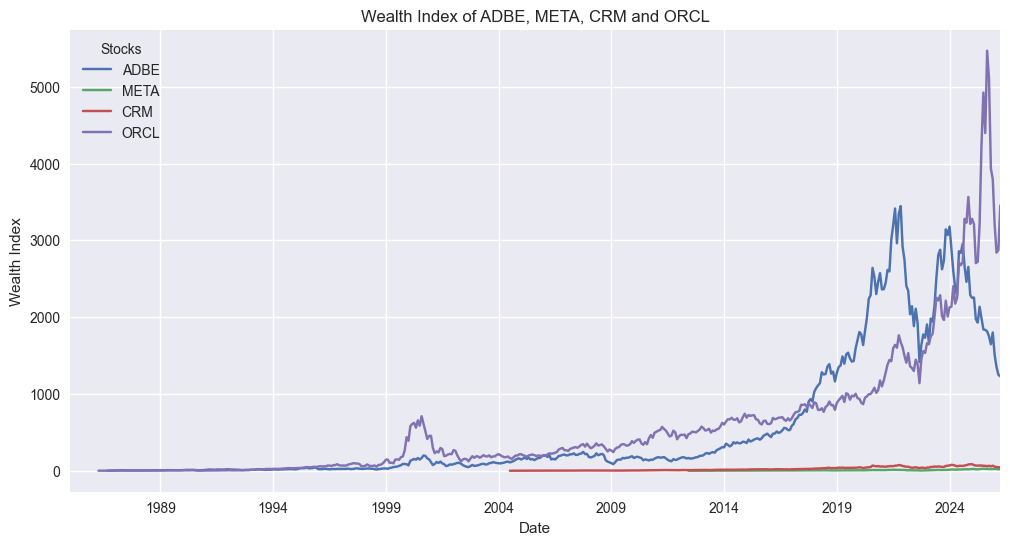

In [223]:
# Construct and plot wealth indices
wealth_index = (1 + monthly_returns).cumprod()
# Plot at least 3 stocks
wealth_index[["ADBE", "META", "CRM", "ORCL"]].plot(figsize=(12, 6))
plt.title("Wealth Index of ADBE, META, CRM and ORCL")
plt.xlabel("Date")  
plt.ylabel("Wealth Index")

# Add a brief interpretation
plt.legend(title="Stocks")
plt.show()
# Interpretation:
# The wealth index shows the growth of an investment in each stock over time.
# ADBE and META have shown significant growth, indicating strong performance.




## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [224]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

In [225]:
# For ABDE ticker:
# - retrieve financial statements using yf.Ticker
AAPL_financials = yf.Ticker("AAPL").financials
print(AAPL_financials)

                                                      2025-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.560000e-01   
Normalized EBITDA                                   1.447480e+11   
Net Income From Continuing Operation Net Minori...  1.120100e+11   
Reconciled Depreciation                             1.169800e+10   
Reconciled Cost Of Revenue                          2.209600e+11   
EBITDA                                              1.447480e+11   
EBIT                                                1.330500e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income                                   1.120100e+11   
Net Income From Continuing And Discontinued Ope...  1.120100e+11   
Total Expenses                                  

In [226]:

# - compute revenue growth
AAPL_revenue = AAPL_financials.loc["Total Revenue"].pct_change()


In [227]:
# - compute operating margin
AAPL_operating_income = AAPL_financials.loc["Operating Income"] 


In [228]:
#store results in a DataFrame
financial_metrics = pd.DataFrame({
    "Revenue Growth": AAPL_rev_growth,
    "Operating Margin": APL_operating_margin
})
print(financial_metrics)

            Revenue Growth  Operating Margin
2025-09-30             NaN          0.319708
2024-09-30       -0.060376          0.315102
2023-09-30       -0.019819          0.298214
2022-09-30        0.028811          0.302887
2021-09-30             NaN               NaN


In [229]:
# For ABDE ticker:
# - retrieve financial statements using yf.Ticker
ADBE_financials = yf.Ticker("ADBE").financials

In [230]:

# - compute revenue growth
ADBE_revenue = ADBE_financials.loc["Total Revenue"].pct_change()


In [231]:
# - compute operating margin
ADBE_operating_income = ADBE_financials.loc["Operating Income"]

In [232]:
#store results in a DataFrame
ADBE_metrics = pd.DataFrame({
    "Revenue Growth": ADBE_revenue,
    "Operating Margin": ADBE_operating_income
})

In [233]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [234]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [235]:
### Selected Stock

### Analyst Rationale
#- Growth outlook:
#- Profitability / quality:
#- Market performance:
#- Key risks:

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: